In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from transformers import BertTokenizer, BertModel
from transformers import get_linear_schedule_with_warmup
from torch.optim import AdamW

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import cohen_kappa_score

from scipy.stats import pearsonr

from tqdm import tqdm


In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 16                  
EPOCHS = 10                      
PATIENCE = 3    
LEARNING_RATE = 2e-5
MAX_LENGTH = 512
RANDOM_SEED = 42
WARMUP_RATIO = 0.1

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(DEVICE)

cuda


In [3]:
df = pd.read_csv(
    "task2_ielts_dataset.csv",
    engine="python",
    on_bad_lines="skip"
)
print("Total essays:", len(df))
df.head(20)


Total essays: 9782


,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length
0,Many people assume that the goal of every coun...,More materials and goods are produced by a cou...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,435
1,Some people believe that giving longer prison ...,There is an opinion which is that the longer p...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,295
2,Some people believe that preserving natural en...,Some people believe that preserving natural en...,NaN,NaN,NaN,NaN,8.0,8.0,NaN,371
3,Some people believe that homework should not b...,The benefits of giving or not giving homework ...,NaN,NaN,NaN,NaN,9.0,9.0,NaN,309
4,Some people believe that governments should pa...,This essay agrees on the need of that governme...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,311
5,Some people believe that governments should pa...,Regarding the suggestions that governments sho...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,267
6,Some people believe that governments should pa...,Nowadays many people argue that univerties gra...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,265
7,Some people believe that governments should pa...,It is believed that governments ought to pay f...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,258
8,Some people believe that governments should pa...,"In recent years, in some countries, including ...",NaN,NaN,NaN,NaN,5.5,5.5,NaN,339
9,Some people believe that governments should pa...,Going to university is an important step in li...,NaN,NaN,NaN,NaN,7.5,7.5,NaN,409


In [4]:
criteria_cols = ["Task_Response", "Coherence_Cohesion", "Lexical_Resource", "Range_Accuracy"]
df_task2 = df.copy()

In [5]:
df_full = df_task2.dropna(subset=criteria_cols)
df_missing = df_task2[df_task2[criteria_cols].isna().any(axis=1)]
print("Full labeled:", len(df_full))
print("Missing:", len(df_missing))

Full labeled: 9120
Missing: 662


In [6]:
print("\n=== MISSING VALUES ===")
print(df_missing.isna().sum())


=== MISSING VALUES ===
Question                0
Essay                   0
Task_Response         662
Coherence_Cohesion    662
Lexical_Resource      662
Range_Accuracy        662
Overall                 0
Overall_Clean           0
Examiner_Comment      649
length                  0
dtype: int64


In [7]:
missing_overall_clean = df_missing[
    df_missing["Overall_Clean"].isna()
]

print("Total missing Overall_Clean:", len(missing_overall_clean))

missing_overall_clean

Total missing Overall_Clean: 0


,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length


In [8]:
df_missing

,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length
0,Many people assume that the goal of every coun...,More materials and goods are produced by a cou...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,435
1,Some people believe that giving longer prison ...,There is an opinion which is that the longer p...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,295
2,Some people believe that preserving natural en...,Some people believe that preserving natural en...,NaN,NaN,NaN,NaN,8.0,8.0,NaN,371
3,Some people believe that homework should not b...,The benefits of giving or not giving homework ...,NaN,NaN,NaN,NaN,9.0,9.0,NaN,309
4,Some people believe that governments should pa...,This essay agrees on the need of that governme...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,311
...,...,...,...,...,...,...,...,...,...,...
657,Write about the following topic.Due to the dev...,"As the huge company extends their bussiness, t...",NaN,NaN,NaN,NaN,4.5,4.5,NaN,231
658,Write about the following topic.Many governmen...,It is often argued that economic progress is t...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,257
659,Write about the following topic.Consumers are ...,"These days, consumers often suffer from the in...",NaN,NaN,NaN,NaN,7.0,7.0,NaN,278
660,Write about the following topic.Consumers are ...,"In recent years, the advancement of cutting-ed...",NaN,NaN,NaN,NaN,8.0,8.0,NaN,483


In [9]:
df[df["Task_Response"].isna()][
    ["Task_Response", "Coherence_Cohesion", 
     "Lexical_Resource", "Range_Accuracy"]
].isna().sum()

Task_Response         662
Coherence_Cohesion    662
Lexical_Resource      662
Range_Accuracy        662
dtype: int64

In [10]:
print("\nDESCRIBE FULL")
print(df_full[criteria_cols + ["Overall_Clean"]].describe())

print("\nDESCRIBE MISSING")
print(df_missing["Overall_Clean"].describe())

df_full["criteria_mean"] = df_full[criteria_cols].mean(axis=1)

print("\nCorrelation mean(criteria) vs Overall:")
print(pearsonr(df_full["criteria_mean"], df_full["Overall_Clean"]))

print("\nMAE consistency:")
print(mean_absolute_error(df_full["criteria_mean"], df_full["Overall_Clean"]))


DESCRIBE FULL
       Task_Response  Coherence_Cohesion  Lexical_Resource  Range_Accuracy  \
count    9120.000000         9120.000000       9120.000000     9120.000000   
mean        6.030482            5.893421          5.718147        5.636404   
std         1.489666            1.620728          1.486432        1.531134   
min         0.000000            0.000000          0.000000        0.000000   
25%         5.500000            5.000000          5.000000        5.000000   
50%         6.500000            6.000000          6.000000        6.000000   
75%         7.000000            7.000000          7.000000        6.500000   
max         9.000000            9.000000          9.000000        9.000000   

       Overall_Clean  
count    9120.000000  
mean        5.879221  
std         1.514604  
min         0.000000  
25%         5.000000  
50%         6.000000  
75%         7.000000  
max         9.000000  

DESCRIBE MISSING
count    662.000000
mean       6.741692
std        1.1095

In [11]:
def round_band(x):
    if pd.isna(x):
        return np.nan

    integer = int(x)
    decimal = x - integer

    if decimal < 0.25:
        return integer
    elif decimal < 0.75:   
        return integer + 0.5
    else:
        return integer + 1

In [12]:
mean_criteria = df_full[criteria_cols].mean(axis=1).apply(round_band)
diff = np.abs(mean_criteria - df_full["Overall_Clean"])

print("Mean diff:", diff.mean())
print("Within 0.5:", np.mean(diff <= 0.5))


Mean diff: 0.0
Within 0.5: 1.0


In [13]:
df_full["input_text"] = (
    "Overall Score: " + df_full["Overall_Clean"].astype(str) +
    " | Word count: " + df_full["length"].astype(str) +
    " | Question: " + df_full["Question"].astype(str) +
    " [SEP] Essay: " + df_full["Essay"].astype(str)
)

In [14]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

encoded_inputs = tokenizer(
    df_full["input_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

input_ids = encoded_inputs["input_ids"]
attention_masks = encoded_inputs["attention_mask"]

In [15]:
criteria = df_full[criteria_cols].values / 9.0
overall = df_full["Overall_Clean"].values / 9.0

criteria = torch.tensor(criteria, dtype=torch.float32)
overall = torch.tensor(overall, dtype=torch.float32)

In [16]:
indices = np.arange(len(df_full))

train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, random_state=RANDOM_SEED # 80 20
)

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, random_state=RANDOM_SEED# 10 10
)

print(len(train_idx), len(val_idx), len(test_idx))

7296 912 912


In [17]:
train_dataset = TensorDataset(
    input_ids[train_idx],
    attention_masks[train_idx],
    criteria[train_idx],
    overall[train_idx]
)

val_dataset = TensorDataset(
    input_ids[val_idx],
    attention_masks[val_idx],
    criteria[val_idx],
    overall[val_idx]
)

test_dataset = TensorDataset(
    input_ids[test_idx],
    attention_masks[test_idx],
    criteria[test_idx],
    overall[test_idx]
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

In [18]:
class BertMultiHead(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = BertModel.from_pretrained("bert-base-uncased")

        self.dropout = nn.Dropout(0.3)

        hidden = self.encoder.config.hidden_size

        self.criteria_head = nn.Sequential(
            nn.Linear(hidden, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, 4)
        )

        self.overall_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )

    def forward(self, input_ids, attention_mask):

        outputs = self.encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        hidden = outputs.last_hidden_state

        pooled = (hidden * attention_mask.unsqueeze(-1)).sum(dim=1) / \
                 attention_mask.sum(dim=1, keepdim=True)

        pooled = self.dropout(pooled)

        criteria = torch.sigmoid(self.criteria_head(pooled))
        overall = torch.sigmoid(self.overall_head(pooled)).squeeze(1)

        return criteria, overall

In [19]:
model = BertMultiHead().to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

criterion = nn.MSELoss()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

logs = []

In [21]:
total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(WARMUP_RATIO * total_steps),
    num_training_steps=total_steps
)

In [22]:
for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")

    model.train()
    train_loss = 0

    for ids, masks, crit, overall in tqdm(train_loader):

        ids = ids.to(DEVICE)
        masks = masks.to(DEVICE)
        crit = crit.to(DEVICE)
        overall = overall.to(DEVICE)

        optimizer.zero_grad()

        crit_pred, overall_pred = model(ids, masks)


        loss_criteria = criterion(crit_pred, crit)
        loss_overall = criterion(overall_pred, overall)

        loss_consistency = criterion(
            crit_pred.mean(dim=1),
            overall
        )

        loss = (
            0.5 * loss_criteria +
            0.3 * loss_overall +
            0.2 * loss_consistency
        )

        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    avg_train = train_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for ids, masks, crit, overall in val_loader:

            ids = ids.to(DEVICE)
            masks = masks.to(DEVICE)
            overall = overall.to(DEVICE)

            _, overall_pred = model(ids, masks)

            loss = criterion(overall_pred, overall)
            val_loss += loss.item()

    avg_val = val_loss / len(val_loader)

    train_losses.append(avg_train)
    val_losses.append(avg_val)

    print("Train Loss:", avg_train)
    print("Val Loss:", avg_val)

    logs.append({
        "epoch": epoch+1,
        "train_loss": avg_train,
        "val_loss": avg_val
    })
    
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        patience_counter = 0
        torch.save(model.state_dict(), "bertbase_task2_model.pt")
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print("Early stopping")
            break




Epoch 1/10


100%|██████████| 456/456 [00:53<00:00,  8.55it/s]


Train Loss: 0.022103666089957154
Val Loss: 0.005721814084896131

Epoch 2/10


100%|██████████| 456/456 [00:53<00:00,  8.56it/s]


Train Loss: 0.002034014379253341
Val Loss: 0.00031490598114926305

Epoch 3/10


...

Train Loss: 0.000783494241388102
Val Loss: 0.00024361119377365532

Epoch 9/10


100%|██████████| 456/456 [00:53<00:00,  8.56it/s]


Train Loss: 0.00076201537529797
Val Loss: 0.00014145133708983563

Epoch 10/10


100%|██████████| 456/456 [00:53<00:00,  8.52it/s]


Train Loss: 0.000734717571296578
Val Loss: 0.00015348221738046655


In [23]:
df_logs = pd.DataFrame(logs)
df_logs.to_csv("training_logs_bert_task2_weak.csv", index=False)

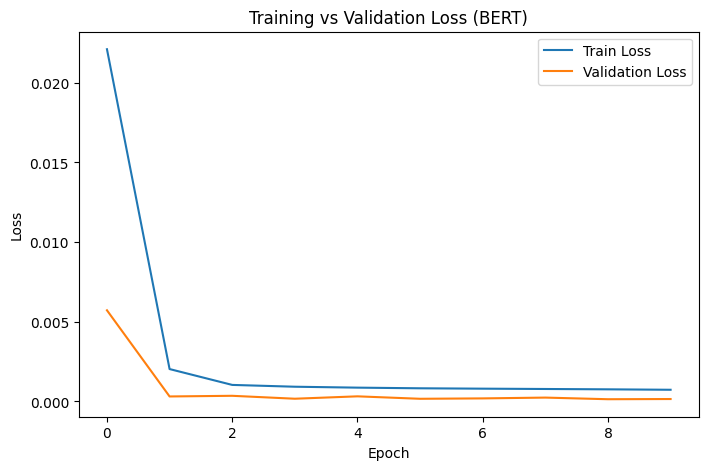

In [24]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss (BERT)")
plt.legend()

plt.show()

In [25]:
model.load_state_dict(torch.load("bertbase_task2_model.pt", map_location=DEVICE))
model.eval()

BertMultiHead(
  (encoder): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_

In [26]:
all_criteria = []
all_overall = []
all_true = []

with torch.no_grad():

    for ids, masks, crit, overall in test_loader:

        ids = ids.to(DEVICE)
        masks = masks.to(DEVICE)

        crit_pred, overall_pred = model(ids, masks)

        crit_pred = torch.clamp(crit_pred, 0, 1)
        overall_pred = torch.clamp(overall_pred, 0, 1)

        all_criteria.append(crit_pred.cpu().numpy())
        all_overall.append(overall_pred.cpu().numpy())
        all_true.append(overall.cpu().numpy())

all_criteria = np.vstack(all_criteria) * 9
overall_pred = np.concatenate(all_overall) * 9
overall_true = np.concatenate(all_true) * 9

In [27]:
vectorized_round = np.vectorize(round_band, otypes=[float])

In [28]:
print(overall_pred[:20])
print(vectorized_round(overall_pred)[:20])

[7.5765076 7.003592  5.9151554 5.9249454 6.468707  3.9483721 8.246116
 6.45415   7.539241  3.4808486 2.8490787 3.941364  3.4539044 3.929231
 7.5748806 3.9275072 7.0089617 7.0123944 8.184162  5.906503 ]
[7.5 7.  6.  6.  6.5 4.  8.  6.5 7.5 3.5 3.  4.  3.5 4.  7.5 4.  7.  7.
 8.  6. ]


In [29]:
mae = mean_absolute_error(overall_true, overall_pred)
rmse = np.sqrt(mean_squared_error(overall_true, overall_pred))
pearson = pearsonr(overall_true, overall_pred)[0]

within_half = np.mean(np.abs(overall_pred - overall_true) <= 0.5)

true_band = np.round(overall_true * 2).astype(int)
pred_band = np.round(overall_pred * 2).astype(int)

qwk = cohen_kappa_score(true_band, pred_band, weights="quadratic")

print("\nTEST RESULTS")
print("MAE:", mae)
print("RMSE:", rmse)
print("Pearson:", pearson)
print("Within ±0.5:", within_half)
print("QWK:", qwk)


TEST RESULTS
MAE: 0.07825707644224167
RMSE: 0.11568077955376507
Pearson: 0.9981457
Within ±0.5: 0.9879385964912281
QWK: 0.9980828220858896


In [30]:
criteria_mean = all_criteria.mean(axis=1)

print("\n CONSISTENCY CHECK")
print("MAE(mean(criteria), overall_true):",
      mean_absolute_error(overall_true, criteria_mean))

print("Pearson:",
      pearsonr(criteria_mean, overall_true)[0])


===== CONSISTENCY CHECK =====
MAE(mean(criteria), overall_true): 0.0914643257856369
Pearson: 0.9979446


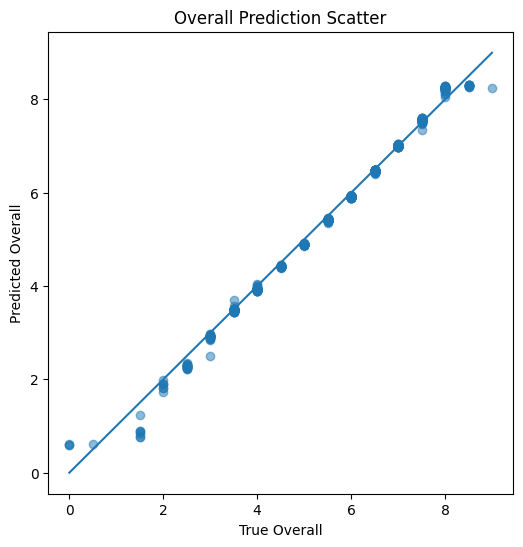

In [31]:
plt.figure(figsize=(6,6))
plt.scatter(overall_true, overall_pred, alpha=0.5)

# y = x (perfect prediction)
plt.plot([0, 9], [0, 9])

plt.xlabel("True Overall")
plt.ylabel("Predicted Overall")
plt.title("Overall Prediction Scatter")

plt.show()

In [32]:

test_df = df_full.iloc[test_idx].copy().reset_index(drop=True)

overall_pred_rounded = vectorized_round(overall_pred)
criteria_rounded = vectorized_round(all_criteria)

test_df["overall_pred_raw"] = overall_pred
test_df["overall_pred"] = overall_pred_rounded

test_df["Task_Response_pred"] = all_criteria[:, 0]
test_df["Coherence_Cohesion_pred"] = all_criteria[:, 1]
test_df["Lexical_Resource_pred"] = all_criteria[:, 2]
test_df["Range_Accuracy_pred"] = all_criteria[:, 3]

test_df["Task_Response_pred_round"] = criteria_rounded[:, 0]
test_df["Coherence_Cohesion_pred_round"] = criteria_rounded[:, 1]
test_df["Lexical_Resource_pred_round"] = criteria_rounded[:, 2]
test_df["Range_Accuracy_pred_round"] = criteria_rounded[:, 3]

test_df["error_raw"] = test_df["overall_pred_raw"] - test_df["Overall_Clean"]
test_df["error_round"] = test_df["overall_pred"] - test_df["Overall_Clean"]

test_df["criteria_mean"] = all_criteria.mean(axis=1)
test_df["criteria_std"] = np.std(all_criteria, axis=1)

test_df.head(10)

,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length,...,Coherence_Cohesion_pred,Lexical_Resource_pred,Range_Accuracy_pred,Task_Response_pred_round,Coherence_Cohesion_pred_round,Lexical_Resource_pred_round,Range_Accuracy_pred_round,error_raw,error_round,criteria_std
0,The range of technology available to people is...,The increasing range of technology available t...,8.0,8.0,7.0,7.0,7.0,7.5,### Task Achievement:\n- The candidate has add...,263,...,7.848626,7.269499,7.266689,8.0,8.0,7.5,7.5,0.076508,0.0,0.272413
1,Some people believe that what children watch o...,Televisions can certainly bring a change in a ...,7.0,7.0,6.5,6.5,7.0,7.0,## Task Achievement:\n- The candidate has addr...,298,...,7.123197,6.847753,6.797656,7.0,7.0,7.0,7.0,0.003592,0.0,0.136813
2,Some people think that public health within a ...,Staying healthy is strongly linked to eating n...,6.0,6.0,6.0,6.0,6.0,6.0,**Task Achievement:**\n\nThe candidate has ade...,312,...,5.939299,5.831513,5.801498,6.0,6.0,6.0,6.0,-0.084845,0.0,0.089359
3,People nowadays tend to have children at older...,"These days, having a child is one of the most ...",6.5,6.0,6.0,6.0,6.5,6.0,**Task Achievement:** (3.5)\n\nThe essay adequ...,250,...,5.965698,5.831600,5.801551,6.0,6.0,6.0,6.0,-0.075055,0.0,0.094194
4,Some people say that what children watch influ...,People have different views about whether it i...,6.5,6.5,6.5,6.5,6.5,6.5,## Task Achievement:\n- The candidate has adeq...,321,...,6.555031,6.307522,6.224530,6.5,6.5,6.5,6.0,-0.031293,0.0,0.157315
5,Some people think news has no connection to pe...,Some think that to read journalism in the pape...,4.0,4.0,4.0,4.0,4.0,4.0,**Task Achievement:**\n- The candidate has add...,323,...,3.981160,3.899557,3.861505,4.0,4.0,4.0,4.0,-0.051628,0.0,0.091264
6,The education of young people is highly priori...,Equitable access to education can change lives...,8.0,8.0,8.0,8.0,8.0,8.0,## Task Achievement:\n- The candidate has addr...,346,...,8.354677,8.012933,8.022305,8.5,8.5,8.0,8.0,0.246116,0.0,0.165297
7,Some people believe that watching TV is bad fo...,People fall into two camps as to whether watc...,6.0,7.0,6.5,6.0,6.0,6.5,## Task Achievement:\nThe candidate has adequa...,247,...,6.569761,6.295655,6.225135,6.5,6.5,6.5,6.0,-0.045850,0.0,0.159050
8,Some people think that robots are important fo...,"In the industrial revolution 5.0, the adoption...",7.5,7.5,7.5,7.5,8.0,7.5,## Task Achievement:\nThe candidate has addres...,316,...,7.782317,7.251703,7.220645,7.5,8.0,7.5,7.0,0.039241,0.0,0.263316
9,Nowadays many job seekers are finding jobs tha...,"To begin with, a lot of people believe they ca...",3.5,3.5,3.0,3.0,3.5,3.5,## Task Achievement:\n- The candidate has addr...,240,...,3.458524,3.380452,3.271278,4.0,3.5,3.5,3.5,-0.019151,0.0,0.179518


In [33]:
df_missing["input_text"] = (
    "Overall Score: " + df_missing["Overall_Clean"].astype(str) +
    " | Word count: " + df_missing["length"].astype(str) +
    " | Question: " + df_missing["Question"].astype(str) +
    " [SEP] Essay: " + df_missing["Essay"].astype(str)
)

encoded_missing = tokenizer(
    df_missing["input_text"].tolist(),
    padding=True,
    truncation=True,
    max_length=MAX_LENGTH,
    return_tensors="pt"
)

missing_ids = encoded_missing["input_ids"]
missing_masks = encoded_missing["attention_mask"]

model.eval()

all_criteria_missing = []
all_overall_missing = []

with torch.no_grad():

    for i in range(0, len(missing_ids), BATCH_SIZE):

        batch_ids = missing_ids[i:i+BATCH_SIZE].to(DEVICE)
        batch_masks = missing_masks[i:i+BATCH_SIZE].to(DEVICE)

        crit_pred, overall_pred = model(batch_ids, batch_masks)

        crit_pred = torch.clamp(crit_pred, 0, 1)
        overall_pred = torch.clamp(overall_pred, 0, 1)

        overall_batch = df_missing["Overall_Clean"].values[i:i+BATCH_SIZE] / 9.0
        overall_batch = torch.tensor(overall_batch, dtype=torch.float32).to(DEVICE)

        scale = overall_batch / (crit_pred.mean(dim=1) + 1e-6)
        crit_pred = crit_pred * scale.unsqueeze(1)

        all_criteria_missing.append(crit_pred.cpu().numpy())
        all_overall_missing.append(overall_pred.cpu().numpy())

all_criteria_missing = np.vstack(all_criteria_missing) * 9
overall_missing_pred = np.concatenate(all_overall_missing) * 9

In [34]:
criteria_missing_rounded = vectorized_round(all_criteria_missing)
overall_missing_rounded = vectorized_round(overall_missing_pred)

missing_df = df_missing.copy().reset_index(drop=True)

missing_df["overall_pred_raw"] = overall_missing_pred
missing_df["overall_pred"] = overall_missing_rounded

missing_df["Task_Response_pred"] = all_criteria_missing[:, 0]
missing_df["Coherence_Cohesion_pred"] = all_criteria_missing[:, 1]
missing_df["Lexical_Resource_pred"] = all_criteria_missing[:, 2]
missing_df["Range_Accuracy_pred"] = all_criteria_missing[:, 3]

missing_df["Task_Response_pred_round"] = criteria_missing_rounded[:, 0]
missing_df["Coherence_Cohesion_pred_round"] = criteria_missing_rounded[:, 1]
missing_df["Lexical_Resource_pred_round"] = criteria_missing_rounded[:, 2]
missing_df["Range_Accuracy_pred_round"] = criteria_missing_rounded[:, 3]

missing_df["criteria_mean"] = all_criteria_missing.mean(axis=1)
missing_df["criteria_std"] = np.std(all_criteria_missing, axis=1)

missing_df.head(10)

,Question,Essay,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall,Overall_Clean,Examiner_Comment,length,...,Task_Response_pred,Coherence_Cohesion_pred,Lexical_Resource_pred,Range_Accuracy_pred,Task_Response_pred_round,Coherence_Cohesion_pred_round,Lexical_Resource_pred_round,Range_Accuracy_pred_round,criteria_mean,criteria_std
0,Many people assume that the goal of every coun...,More materials and goods are produced by a cou...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,435,...,6.674088,6.631637,6.399415,6.294822,6.5,6.5,6.5,6.5,6.499990,0.157995
1,Some people believe that giving longer prison ...,There is an opinion which is that the longer p...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,295,...,6.139140,6.049807,5.916580,5.894439,6.0,6.0,6.0,6.0,5.999991,0.099928
2,Some people believe that preserving natural en...,Some people believe that preserving natural en...,NaN,NaN,NaN,NaN,8.0,8.0,NaN,371,...,8.147236,8.166344,7.835449,7.850936,8.0,8.0,8.0,8.0,7.999991,0.157040
3,Some people believe that homework should not b...,The benefits of giving or not giving homework ...,NaN,NaN,NaN,NaN,9.0,9.0,NaN,309,...,9.178894,9.202194,8.806527,8.812346,9.0,9.0,9.0,9.0,8.999990,0.190743
4,Some people believe that governments should pa...,This essay agrees on the need of that governme...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,311,...,5.817092,5.464834,5.439417,5.278618,6.0,5.5,5.5,5.5,5.499990,0.196510
5,Some people believe that governments should pa...,Regarding the suggestions that governments sho...,NaN,NaN,NaN,NaN,6.0,6.0,NaN,267,...,6.130492,6.051979,5.923771,5.893720,6.0,6.0,6.0,6.0,5.999990,0.095964
6,Some people believe that governments should pa...,Nowadays many people argue that univerties gra...,NaN,NaN,NaN,NaN,5.5,5.5,NaN,265,...,5.809821,5.455452,5.438761,5.295926,6.0,5.5,5.5,5.5,5.499990,0.189321
7,Some people believe that governments should pa...,It is believed that governments ought to pay f...,NaN,NaN,NaN,NaN,6.5,6.5,NaN,258,...,6.668093,6.652096,6.382892,6.296881,6.5,6.5,6.5,6.5,6.499990,0.163065
8,Some people believe that governments should pa...,"In recent years, in some countries, including ...",NaN,NaN,NaN,NaN,5.5,5.5,NaN,339,...,5.816339,5.460487,5.443228,5.279908,6.0,5.5,5.5,5.5,5.499990,0.195765
9,Some people believe that governments should pa...,Going to university is an important step in li...,NaN,NaN,NaN,NaN,7.5,7.5,NaN,409,...,7.745010,7.787263,7.250118,7.217573,7.5,8.0,7.5,7.0,7.499991,0.266813


In [ ]:
criteria_cols = ["Task_Response", "Coherence_Cohesion", "Lexical_Resource", "Range_Accuracy"]

pred_round_cols = ["Task_Response_pred_round",
                   "Coherence_Cohesion_pred_round",
                   "Lexical_Resource_pred_round",
                   "Range_Accuracy_pred_round"]

df_clean = df_task2.copy()


mask_missing = df_clean[criteria_cols].isna().any(axis=1)

df_clean.loc[mask_missing, criteria_cols] = missing_df[pred_round_cols].values

df_clean.to_csv("task2_ielts_dataset_criteria.csv", index=False)
